# Superstore Sales & Pricing Analysis

## Introduction

The dataset was downloaded from [Kaggle](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) and contains retail transaction 
records from a fictional US superstore, including sales, profit, discount, 
and shipping information across multiple regions and product categories.

The goal of this analysis is to identify key drivers of sales and profit, 
and explore how discounting strategies impact overall business performance.

In [28]:
#import the necessary Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Part 1 - Data Cleaning

In [29]:
df = pd.read_csv('Superstore.csv', encoding='latin1') #read the dataset
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [30]:
df.info() #check all columns and the data type

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [31]:
df.drop('Row ID', axis=1, inplace=True, errors='ignore') #Dropping the Row ID column as it does not help much in the process of data analysis
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y') #convert Order dates to pandas datetime format
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')   #convert shipping dates to pandas datetime format

In [32]:
df.info() #check all columns and the data type

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   str           
 1   Order Date     9994 non-null   datetime64[us]
 2   Ship Date      9994 non-null   datetime64[us]
 3   Ship Mode      9994 non-null   str           
 4   Customer ID    9994 non-null   str           
 5   Customer Name  9994 non-null   str           
 6   Segment        9994 non-null   str           
 7   Country        9994 non-null   str           
 8   City           9994 non-null   str           
 9   State          9994 non-null   str           
 10  Postal Code    9994 non-null   int64         
 11  Region         9994 non-null   str           
 12  Product ID     9994 non-null   str           
 13  Category       9994 non-null   str           
 14  Sub-Category   9994 non-null   str           
 15  Product Name   9994 non-null   s

In [33]:
print(df.isnull().sum()) #check if there is null value for each column

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## Part 2 - Sales Overview

Which product categories generate the most profit?

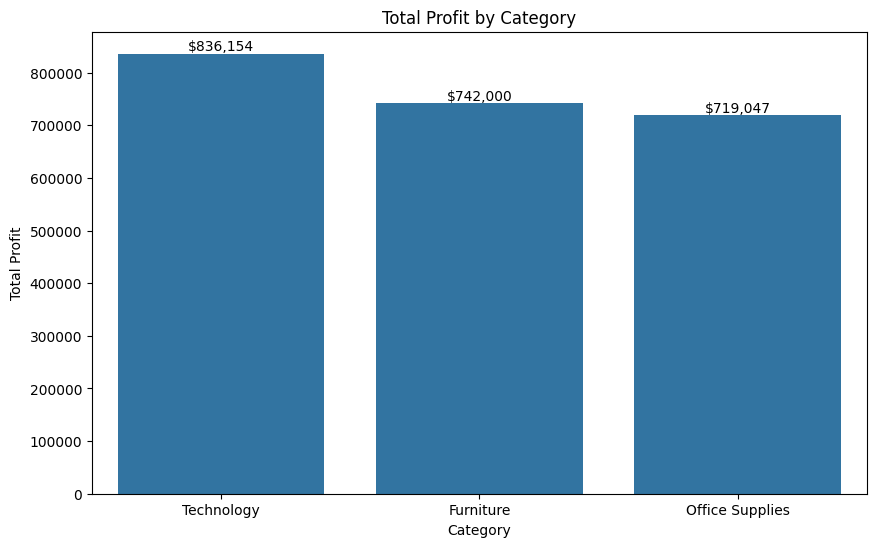

In [34]:
category_profit = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_profit.index, y=category_profit.values)
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.bar_label(plt.gca().containers[0], labels=[f'${v:,.0f}' for v in category_profit.values])
plt.show()

Which product sub-categories generate the most profit?

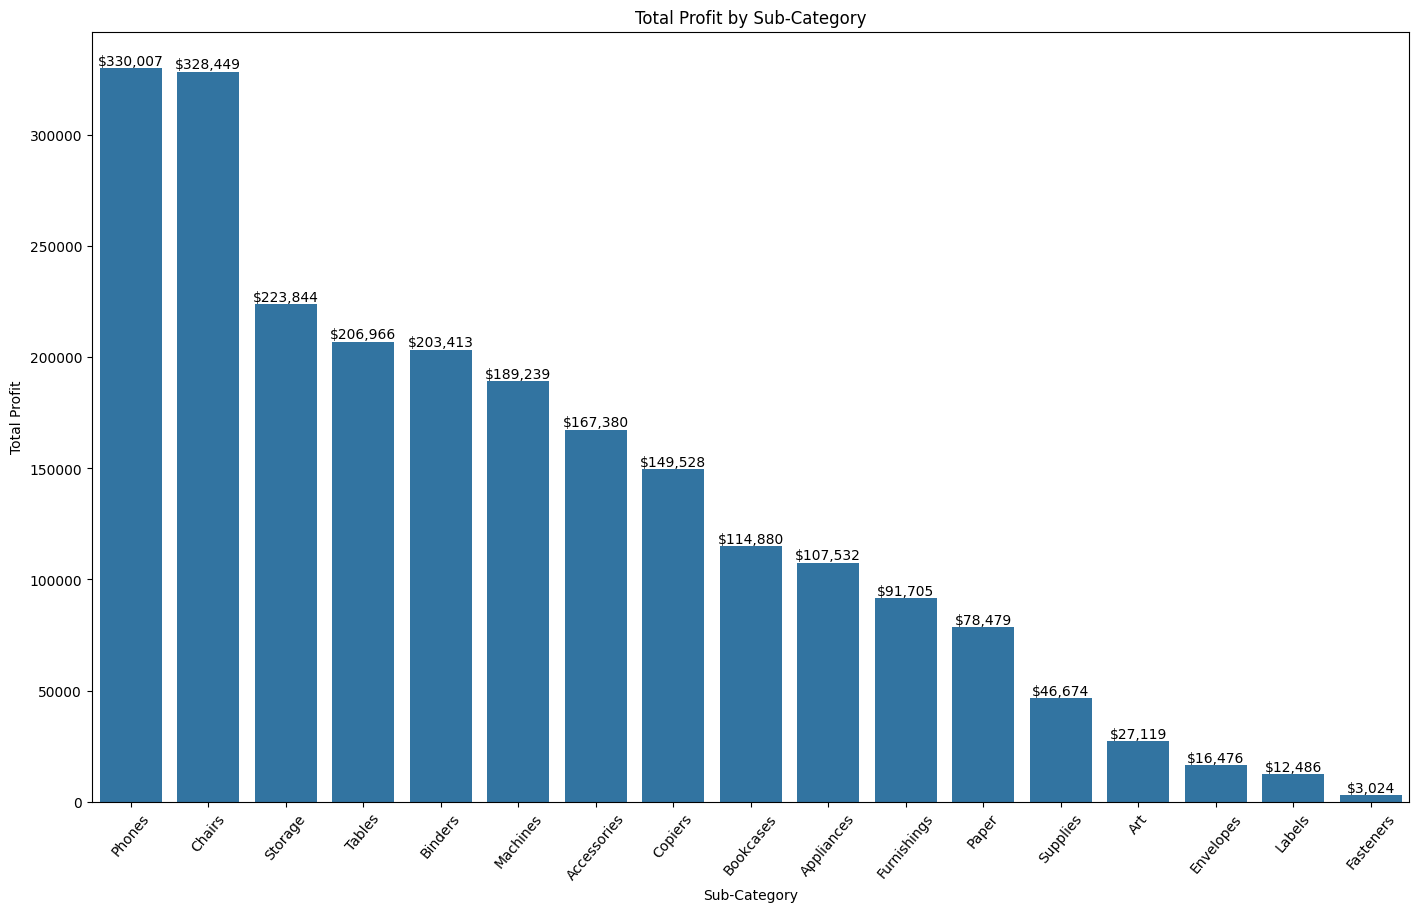

In [35]:
subcategory_profit = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(17, 10))
sns.barplot(x=subcategory_profit.index, y=subcategory_profit.values)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=50) #rotate the header for easier reding
plt.bar_label(plt.gca().containers[0], labels=[f'${v:,.0f}' for v in subcategory_profit.values])
plt.show()

Which customer segment is most valuable? <br>
Compare Consumer vs Corporate vs Home Office segments by sales and profit

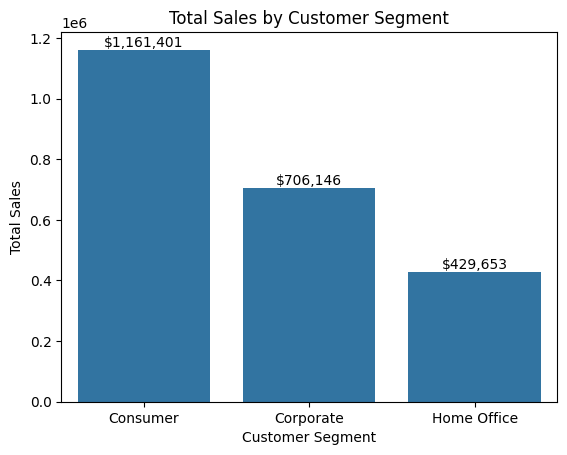

In [36]:
customer_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

sns.barplot(x=customer_sales.index, y=customer_sales.values)
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.bar_label(plt.gca().containers[0], labels=[f'${v:,.0f}' for v in customer_sales.values])
plt.show()

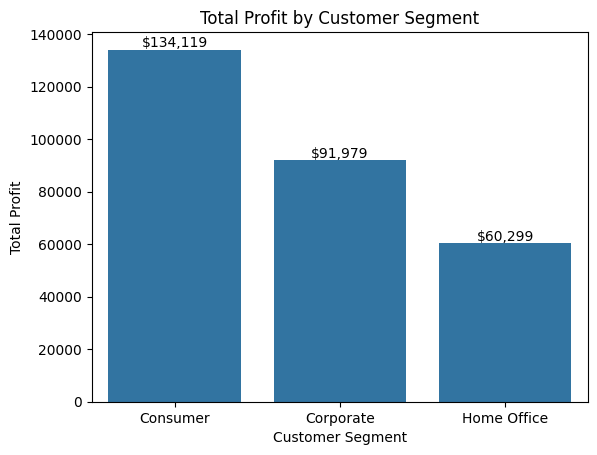

In [37]:
customer_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

sns.barplot(x=customer_profit.index, y=customer_profit.values)
plt.title('Total Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit')
plt.bar_label(plt.gca().containers[0], labels=[f'${v:,.0f}' for v in customer_profit.values])
plt.show()

Both total sales and total profit follow the same pattern — Consumer > Corporate > Home Office

Which region performs best?<br>
Sales and profit breakdown by region

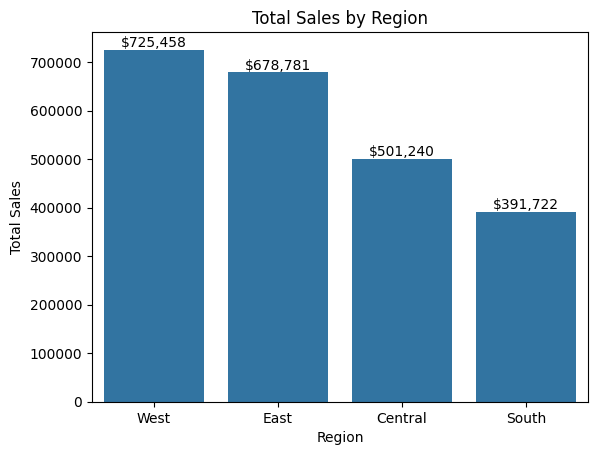

In [38]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False) #sales by region

sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.bar_label(plt.gca().containers[0], labels=[f'${v:,.0f}' for v in region_sales.values])
plt.show()

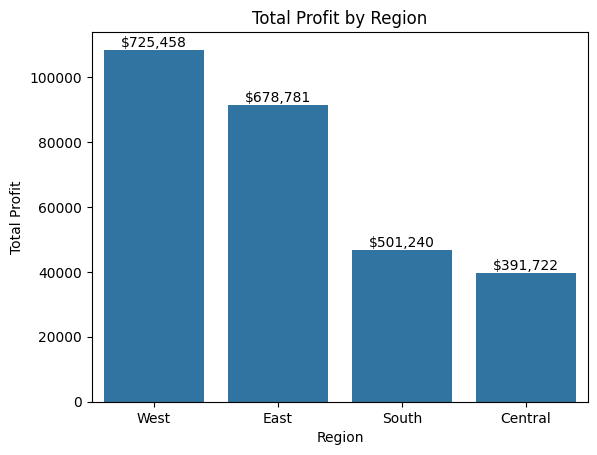

In [39]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False) #profit by region

sns.barplot(x=region_profit.index, y=region_profit.values)
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.bar_label(plt.gca().containers[0], labels=[f'${v:,.0f}' for v in region_sales.values])
plt.show()

## Part 3 - Discount and Profit Analysis

Are discounts hurting us?<br>
What is the relationship between discount rate and profit margin?

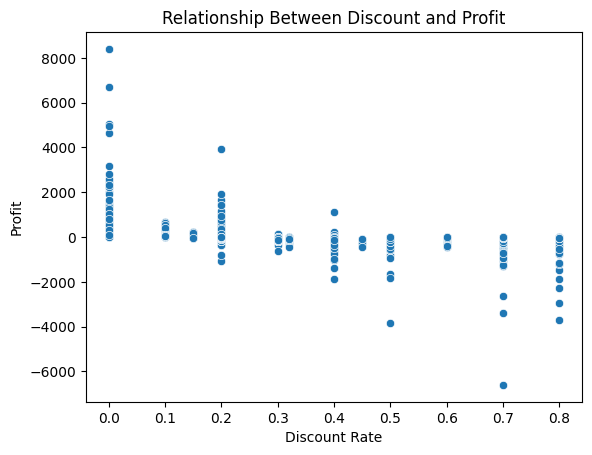

In [40]:
sns.scatterplot(data=df, x='Discount', y='Profit') #create a scatter plot
plt.title('Relationship Between Discount and Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.show()

The scatter plot shows a negative relationship between discount rate and profit.<br>
 Let's fit a Simple Linear Regression (SLR) model to quantify this further.

In [46]:
import statsmodels.formula.api as smf #import stats formula api
import statsmodels.api as smapi #import statsmodel api
import statsmodels.stats as stats #import statsmodel stats
lm_model = smf.ols(formula='Profit ~ Discount', data=df) #define the mode

In [41]:
Fit_lm_model = lm_model.fit() # fit the model lm_model
print(Fit_lm_model.summary()) #print summary of the model

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     505.7
Date:                Fri, 31 Jul 2026   Prob (F-statistic):          2.70e-109
Time:                        17:52:13   Log-Likelihood:                -68465.
No. Observations:                9994   AIC:                         1.369e+05
Df Residuals:                    9992   BIC:                         1.369e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     67.5594      2.867     23.565      0.0

In [47]:
Fit_lm_model = lm_model.fit() # fit the model lm_model
print(Fit_lm_model.summary()) #print summary of the model

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     505.7
Date:                Fri, 31 Jul 2026   Prob (F-statistic):          2.70e-109
Time:                        17:55:59   Log-Likelihood:                -68465.
No. Observations:                9994   AIC:                         1.369e+05
Df Residuals:                    9992   BIC:                         1.369e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     67.5594      2.867     23.565      0.0

$$
\hat{\text{Profit}} = 67.56 - 249.05 \times \text{Discount}
$$

The model was statistically significant, with **F(1, 9992) = 505.70, p < .001**, indicating that Discount is a significant predictor of Profit.

Suggesting that as Discount increases by one unit, Profit decreases by approximately **249.05 units**, on average.

The model explained **4.8%** of the variation in Profit (**R² = 0.048**), indicating that Discount alone is a relatively weak predictor of Profit.


## Part 4 — ANCOVA — Does discount affect profit differently across categories?

In [48]:
ancova_model = smf.ols(formula='Profit ~ Discount * C(Category)', data=df).fit()

print(ancova_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     186.2
Date:                Fri, 31 Jul 2026   Prob (F-statistic):          3.41e-190
Time:                        17:57:01   Log-Likelihood:                -68267.
No. Observations:                9994   AIC:                         1.365e+05
Df Residuals:                    9988   BIC:                         1.366e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

An ANCOVA model was used to examine whether the relationship between Discount and Profit differed across product Categories.

The interaction between **Discount and Category** was statistically significant (**p < .001**), indicating that the effect of Discount on Profit varies by product category.

- For **Furniture**, each one-unit increase in Discount decreased Profit by approximately **362.53** units.
- For **Office Supplies**, the decrease was approximately **150.01** units, indicating that discounts have a smaller negative impact on profit than in Furniture.
- For **Technology**, the decrease was approximately **814.33** units, indicating that discounts have a much stronger negative impact on profit than in Furniture.

## Part 5 — Conclusion & Business Recommendations

These findings suggest that discount strategies should differ by product category. Technology products appear to be much more sensitive to discounting, while Office Supplies are less affected. Therefore, managers should avoid offering large discounts on Technology products and instead consider category-specific pricing and promotional strategies.